# Project Title
# Electric Vehicle Sales Forecasting in India using Machine Learning

# Problem Statement

Electric vehicle adoption in India has been growing rapidly due to environmental awareness, government incentives, and technological advancements. Understanding EV sales trends and forecasting future demand is important for manufacturers, policymakers, and infrastructure planners.

This project analyzes historical EV sales data across Indian states and builds machine learning models to forecast future EV demand using time-series feature engineering and ensemble regression models.

## Forecasting Goal
The goal of this project is to forecast monthly total EV sales in India using historical EV sales data, lag-based forecasting features, seasonal patterns, and machine learning models.

### Step 1 — Data Collection & Environment Setup

#### Objective: To prepare the analysis environment and load all Ev Sales datasets required for the project.

#### Purpose: 
The Purpose of this step is to make sure that all required datasets are available in the Jupyter Notebook environment and that the necessary libraries for data analysis, visualization, and machine learning are successfully imported. This step also confirms that the dataset files are properly loaded and accessible before starting data preprocessing or further analysis.

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor

import joblib
import warnings
warnings.filterwarnings("ignore")

In [2]:
data_path = "."

### Step 2 — Data Loading and Dataset Integration

#### Objective : To import the EV sales dataset into the Jupyter Notebook and ensure it is properly prepared for data cleaning, exploratory analysis, and predictive modeling.

Purpose : The EV sales dataset must be loaded into the analysis environment so that sales records across different states and time periods can be examined collectively. This step ensures the dataset is properly imported and prepared for data cleaning, exploration, and machine learning analysis.

In [3]:
from pathlib import Path

possible_paths = [
    Path("EV SALES INDIA  .csv"),
    Path("/mnt/data/EV SALES INDIA  .csv"),
    Path("./EV SALES INDIA  .csv")
]

file_path = next((path for path in possible_paths if path.exists()), None)
if file_path is None:
    raise FileNotFoundError("EV_SALES_INDIA.csv was not found in the working directory or /mnt/data.")

In [4]:
df = pd.read_csv(file_path)
print(f"Dataset path : {file_path}")

Dataset path : EV SALES INDIA  .csv


In [5]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (96845, 8)


In [6]:
df.head()

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014.0,jan,1/1/2014,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0
1,2014.0,jan,1/1/2014,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0
2,2014.0,jan,1/1/2014,Andhra Pradesh,AMBULANCE,Others,Others,0.0
3,2014.0,jan,1/1/2014,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0
4,2014.0,jan,1/1/2014,Andhra Pradesh,BUS,Bus,Bus,0.0


In [7]:
df.tail()

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
96840,2023.0,dec,12/1/2023,Andaman & Nicobar Island,MOTOR CAR,4-Wheelers,4W_Personal,1.0
96841,2023.0,dec,12/1/2023,Andaman & Nicobar Island,MOTOR CYCLE/SCOOTER-USED FOR HIRE,2-Wheelers,2W_Shared,5.0
96842,2023.0,dec,12/1/2023,Andaman & Nicobar Island,OMNI BUS,Bus,Bus,0.0
96843,2023.0,dec,12/1/2023,Andaman & Nicobar Island,THREE WHEELER (GOODS),3-Wheelers,3W_Goods,0.0
96844,2023.0,dec,12/1/2023,Andaman & Nicobar Island,THREE WHEELER (PASSENGER),3-Wheelers,3W_Shared,0.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               96845 non-null  float64
 1   Month_Name         96845 non-null  object 
 2   Date               96845 non-null  object 
 3   State              96845 non-null  object 
 4   Vehicle_Class      96845 non-null  object 
 5   Vehicle_Category   96845 non-null  object 
 6   Vehicle_Type       96845 non-null  object 
 7   EV_Sales_Quantity  96845 non-null  float64
dtypes: float64(2), object(6)
memory usage: 5.9+ MB


### Step 3 — Data Understanding (Dataset Exploration)

#### Objective : To understand the structure, quality, and statistical characteristics of the EV sales dataset before performing data cleaning and feature engineering.

Purpose : Before performing analysis or building a machine learning model, it is essential to examine the dataset to understand its overall structure and quality. This includes checking data types, identifying missing values, detecting duplicate records, analyzing the statistical distribution of numerical variables, and reviewing unique values in categorical columns. This step helps detect potential data issues and ensures the dataset is reliable and properly prepared for further analysis and modeling.

In [9]:
df.info()

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               96845 non-null  float64
 1   Month_Name         96845 non-null  object 
 2   Date               96845 non-null  object 
 3   State              96845 non-null  object 
 4   Vehicle_Class      96845 non-null  object 
 5   Vehicle_Category   96845 non-null  object 
 6   Vehicle_Type       96845 non-null  object 
 7   EV_Sales_Quantity  96845 non-null  float64
dtypes: float64(2), object(6)
memory usage: 5.9+ MB


Index(['Year', 'Month_Name', 'Date', 'State', 'Vehicle_Class',
       'Vehicle_Category', 'Vehicle_Type', 'EV_Sales_Quantity'],
      dtype='object')

In [10]:
df.describe()

,Year,EV_Sales_Quantity
count,96845.000000,96845.000000
mean,2018.622768,37.108896
std,2.895581,431.566675
min,2014.000000,0.000000
25%,2016.000000,0.000000
50%,2019.000000,0.000000
75%,2021.000000,0.000000
max,2024.000000,20584.000000


In [11]:
df.isnull().sum()

Year                 0
Month_Name           0
Date                 0
State                0
Vehicle_Class        0
Vehicle_Category     0
Vehicle_Type         0
EV_Sales_Quantity    0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

### Step 4 — Data Cleaning & Data Preparation

#### Objective : To clean and transform the Uber trip dataset so that it becomes structured and ready for analysis and machine learning.

Purpose : Raw datasets may contain columns that are not stored in the most suitable format for analysis. In this dataset, the date-related information needs to be properly structured so that time-based patterns in EV sales can be analyzed effectively. Therefore, the date column is converted into an appropriate datetime format, and useful time-related features such as year and month are extracted. These features help in exploratory data analysis and improve the performance of machine learning models used for EV sales prediction.

In [13]:
df["Date"] = pd.to_datetime(df["Date"])

In [14]:
df["Year"] = df["Date"].dt.year

In [15]:
df["Month"] = df["Date"].dt.month

In [16]:
df["Month_Name"] = df["Date"].dt.month_name()

In [17]:
df["Quarter"] = df["Date"].dt.quarter

In [18]:
df["Day"] = df["Date"].dt.day

In [19]:
df.head()

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity,Month,Quarter,Day
0,2014,January,2014-01-01,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0,1,1,1
1,2014,January,2014-01-01,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0,1,1,1
2,2014,January,2014-01-01,Andhra Pradesh,AMBULANCE,Others,Others,0.0,1,1,1
3,2014,January,2014-01-01,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0,1,1,1
4,2014,January,2014-01-01,Andhra Pradesh,BUS,Bus,Bus,0.0,1,1,1


In [20]:
df.tail()

,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity,Month,Quarter,Day
96840,2023,December,2023-12-01,Andaman & Nicobar Island,MOTOR CAR,4-Wheelers,4W_Personal,1.0,12,4,1
96841,2023,December,2023-12-01,Andaman & Nicobar Island,MOTOR CYCLE/SCOOTER-USED FOR HIRE,2-Wheelers,2W_Shared,5.0,12,4,1
96842,2023,December,2023-12-01,Andaman & Nicobar Island,OMNI BUS,Bus,Bus,0.0,12,4,1
96843,2023,December,2023-12-01,Andaman & Nicobar Island,THREE WHEELER (GOODS),3-Wheelers,3W_Goods,0.0,12,4,1
96844,2023,December,2023-12-01,Andaman & Nicobar Island,THREE WHEELER (PASSENGER),3-Wheelers,3W_Shared,0.0,12,4,1


### Business Questions

How has EV adoption grown over time in India?

Which states contribute the most to EV sales?

What seasonal patterns exist in EV demand?

Which factors influence EV sales the most?

Can machine learning models accurately forecast future EV demand?

### Step 5 — Exploratory Data Analysis (EDA)

#### Objective : To perform exploratory data analysis (EDA) on the EV sales dataset in order to identify sales trends across different states, time periods, and vehicle categories.

Purpose : Exploratory Data Analysis (EDA) helps convert raw EV sales data into meaningful insights by identifying patterns and trends through visualization and statistical analysis. In this step, we aim to answer key questions such as:

1. Which states have the highest EV sales?
2. How do EV sales vary across different months and years?
3. Which vehicle categories or classes contribute most to EV sales?
4. What trends can be observed in EV adoption over time?

Understanding these patterns helps reveal regional adoption trends, market demand, and growth opportunities in the electric vehicle sector.

In [21]:
feature_df = df.copy()
    
yearly_sales = feature_df.groupby("Year", as_index=False)["EV_Sales_Quantity"].sum()
monthly_sales = feature_df.groupby("Month", as_index=False)["EV_Sales_Quantity"].sum()
top_states = (
    feature_df.groupby("State", as_index=False)["EV_Sales_Quantity"]
    .sum()
    .sort_values("EV_Sales_Quantity", ascending=False)
    .head(10)
)
category_sales = feature_df.groupby("Vehicle_Category", as_index=False)["EV_Sales_Quantity"].sum()

#### 1. EV Sales by Month 

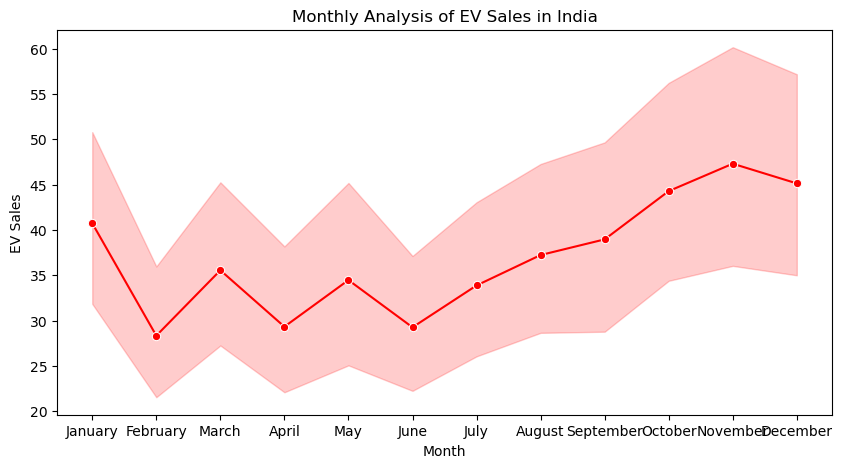

In [22]:
plt.figure(figsize=(10,5))
plt.title('Monthly Analysis of EV Sales in India')
sns.lineplot(x='Month_Name', y='EV_Sales_Quantity', data=df,
marker='o', color='r')
plt.xlabel('Month')
plt.ylabel('EV Sales');

Observation:
The monthly EV sales trend shows fluctuations in the first half of the year, with lower sales around February, April, and June. From July onward, EV sales gradually increase, reaching the highest levels during October and November before slightly declining in December.

Key Insight:
Higher EV sales in the later months suggest seasonal demand patterns, possibly influenced by festive seasons and increased consumer purchasing activity in India.

#### 2. EV Sales by Year

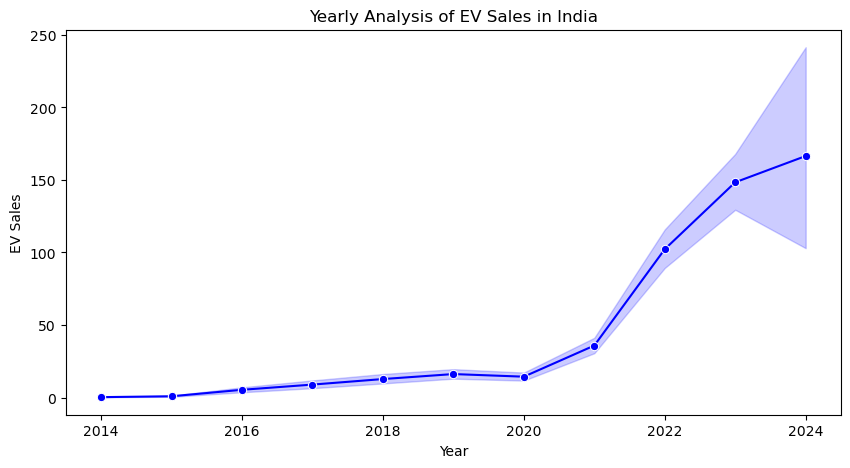

In [23]:
plt.figure(figsize=(10,5))
plt.title('Yearly Analysis of EV Sales in India')
sns.lineplot(x='Year', y='EV_Sales_Quantity', data=df,
marker='o', color='b')
plt.xlabel('Year')
plt.ylabel('EV Sales');

Observation: The yearly EV sales trend in India shows a gradual increase from 2014 to around 2019, followed by a slight dip around 2020. After 2021, EV sales rise sharply, with a significant surge between 2022 and 2024, indicating rapid growth in electric vehicle adoption across the country.

Key Insight: The rapid rise in recent years indicates growing EV adoption in India, likely supported by government policies, infrastructure development, and increasing consumer interest in sustainable transportation.

#### 3. EV Sales by States across India

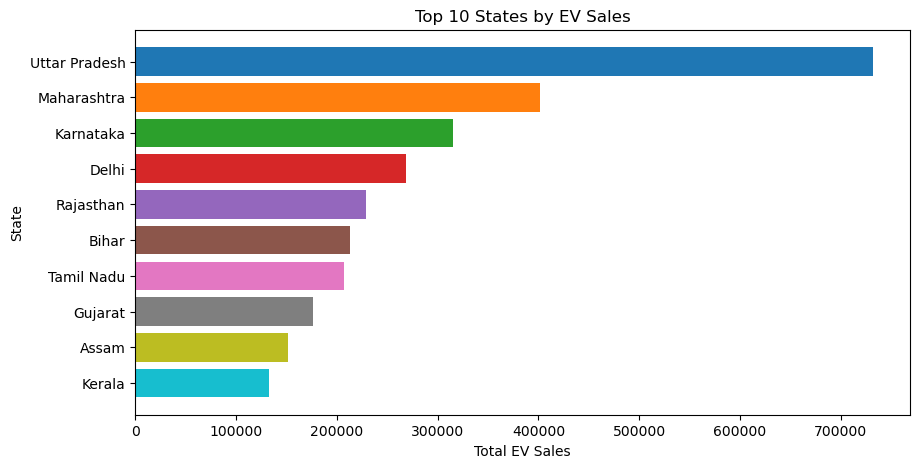

In [24]:
plt.figure(figsize=(10, 5))
plt.barh(top_states["State"], top_states["EV_Sales_Quantity"], color=plt.cm.tab10.colors)
plt.title("Top 10 States by EV Sales")
plt.xlabel("Total EV Sales")
plt.ylabel("State")
plt.gca().invert_yaxis()
plt.show()

Observation: Uttar Pradesh leads EV sales among Indian states, followed by Maharashtra and Karnataka, while states like Assam and Kerala have comparatively lower sales within the top ten.

Key Insight: Higher EV adoption in major states suggests that population size, urbanization, and policy support significantly influence EV market growth.

#### 4. EV Sales By Vehicle Category

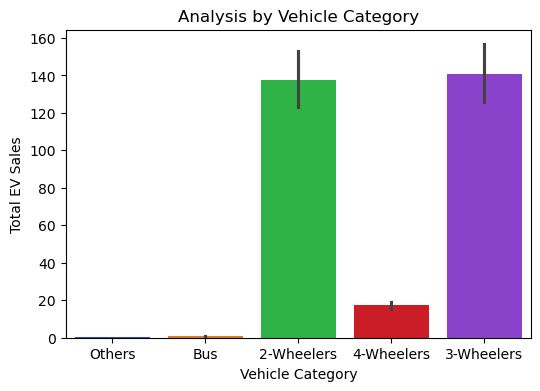

In [25]:
plt.figure(figsize=(6,4))
sns.barplot(x='Vehicle_Category',
y='EV_Sales_Quantity',data=df, hue='Vehicle_Category',
palette='bright')
plt.title('Analysis by Vehicle Category')
plt.xlabel('Vehicle Category')
plt.ylabel('Total EV Sales')
plt.xticks(rotation=0);


Observation: The chart shows that 3-wheelers and 2-wheelers dominate EV sales, contributing the largest share among all vehicle categories. In contrast, 4-wheelers have moderate sales, while buses and other vehicle types contribute very small portions to the total EV sales.

Key Insight: The dominance of 2-wheelers and 3-wheelers indicates that electric mobility adoption in India is primarily driven by affordable and practical transport options, commonly used for daily commuting and commercial purposes. Lower adoption of electric buses and 4-wheelers may be due to higher costs, infrastructure requirements, and slower transition in these segments.

#### 5. EV Sales by Vehicle Type

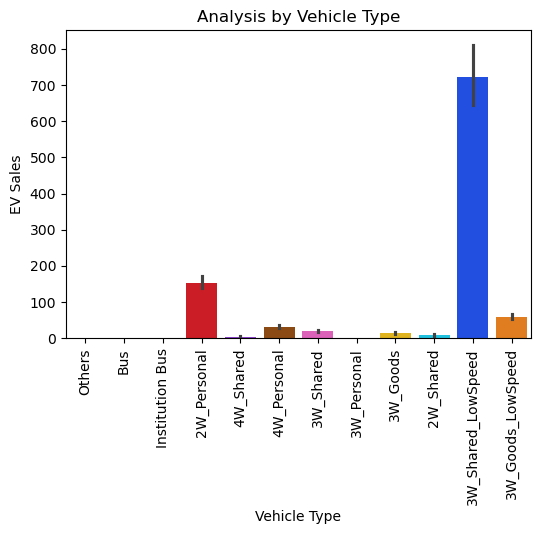

In [26]:
plt.figure(figsize=(6,4))
sns.barplot(x='Vehicle_Type', y='EV_Sales_Quantity',data=df,
hue='Vehicle_Type', palette='bright')
plt.title('Analysis by Vehicle Type')
plt.xlabel('Vehicle Type')
plt.ylabel('EV Sales')
plt.xticks(rotation=90);

Observation: The chart shows that 3W_Shared_LowSpeed vehicles contribute the highest EV sales among all vehicle types. 2W_Personal vehicles also have significant sales, indicating strong adoption in the two-wheeler segment. Other vehicle types such as 3W_Shared, 3W_Goods, and 4W_Personal show moderate sales, while buses and some specialized vehicle types contribute relatively smaller portions.

Key Insight: EV adoption in India is largely driven by shared mobility and affordable personal two-wheelers, which are widely used for daily commuting and commercial transportation.

#### 6. EV Sales Demand Heatmap (Year vs Month)

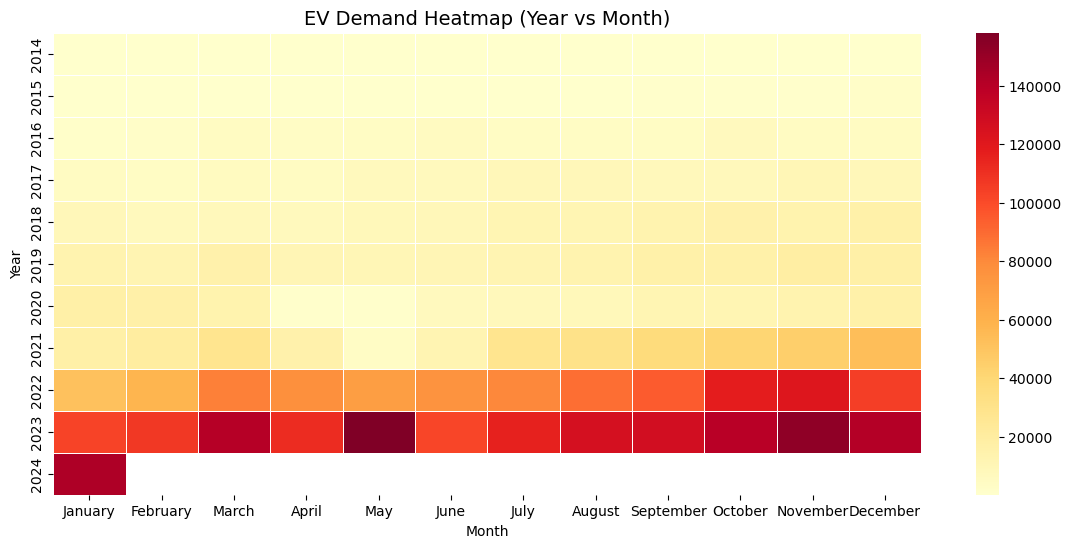

In [27]:
month_order = (['January', 'February', 'March', 'April', 'May', 'June', 'July',
                'August', 'September', 'October', 'November', 'December'])


ev_heatmap_data = df.pivot_table(
    values='EV_Sales_Quantity',
    index='Year',
    columns='Month_Name',
    aggfunc='sum'
)
ev_heatmap_data = ev_heatmap_data.reindex(columns=month_order)

# Plot heatmap
plt.figure(figsize=(14, 6))
sns.heatmap(ev_heatmap_data, cmap='YlOrRd', linewidths=0.5)

plt.title('EV Demand Heatmap (Year vs Month)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Year')
plt.show()

Observation: EV sales were relatively low and stable from 2014 to 2020, indicated by lighter color intensity across most months. From 2021 onwards, the color gradually becomes darker, showing a noticeable increase in EV sales. The highest sales intensity appears in 2023 and 2024, particularly during the later months of the year.

Key Insight: The pattern indicates rapid growth in EV adoption in India in recent years, suggesting expanding market demand and stronger acceptance of electric mobility.

#### 7. EV Sales Demand Heatmap (State vs Month)

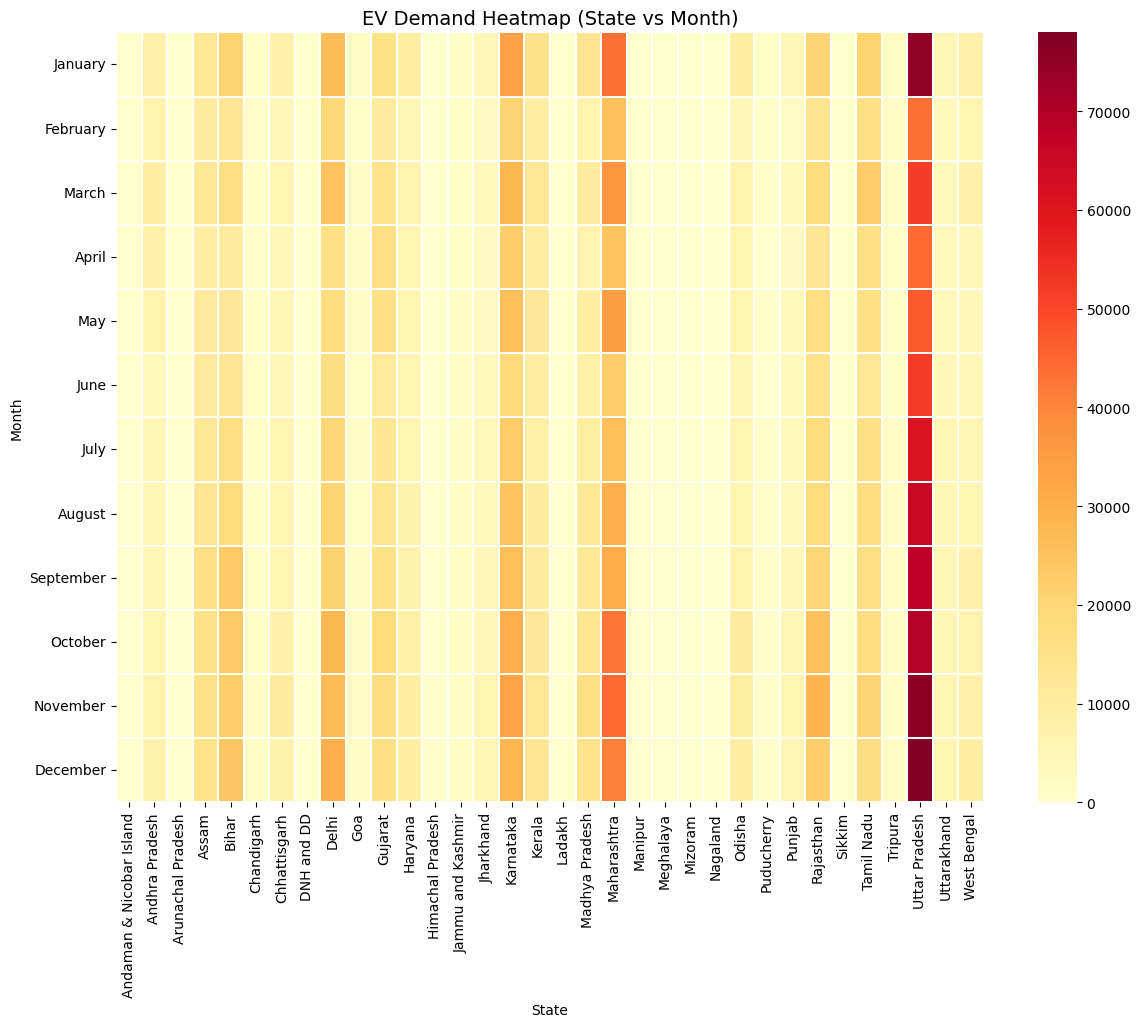

In [28]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
               'August', 'September', 'October', 'November', 'December']

state_month_heatmap = df.pivot_table(
    values='EV_Sales_Quantity',
    index='Month_Name',
    columns='State',
    aggfunc='sum'
)

state_month_heatmap = state_month_heatmap.reindex(index=month_order)

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(state_month_heatmap, cmap='YlOrRd', linewidths=0.3)

plt.title('EV Demand Heatmap (State vs Month)', fontsize=14)
plt.xlabel('State')
plt.ylabel('Month')
plt.show()

Observation: EV sales across different states and months. A few states display consistently higher sales intensity, indicated by darker shades, while many other states show lighter colors, reflecting relatively lower EV sales. Some months also appear slightly darker across multiple states, suggesting periods of higher EV demand.

Key Insight:
The uneven distribution of EV sales indicates that EV adoption is concentrated in certain regions, highlighting important markets that drive the growth of electric vehicles in India.


#### 8. Market Shares Comparison 

#### Top 5 vs Bottom 5 States

In [29]:
state_sales = feature_df.groupby('State')['EV_Sales_Quantity'].sum().sort_values(ascending=False)
state_sales

State
Uttar Pradesh               732074.0
Maharashtra                 401535.0
Karnataka                   315498.0
Delhi                       268538.0
Rajasthan                   228573.0
Bihar                       213465.0
Tamil Nadu                  206902.0
Gujarat                     176713.0
Assam                       151917.0
Kerala                      133246.0
Madhya Pradesh              133182.0
Odisha                       86823.0
Haryana                      85250.0
West Bengal                  78112.0
Andhra Pradesh               77356.0
Chhattisgarh                 75275.0
Uttarakhand                  57606.0
Punjab                       49285.0
Jharkhand                    47871.0
Tripura                      18346.0
Goa                          17382.0
Jammu and Kashmir            16840.0
Chandigarh                   11453.0
Puducherry                    5139.0
Himachal Pradesh              2886.0
Manipur                       1284.0
DNH and DD                     4

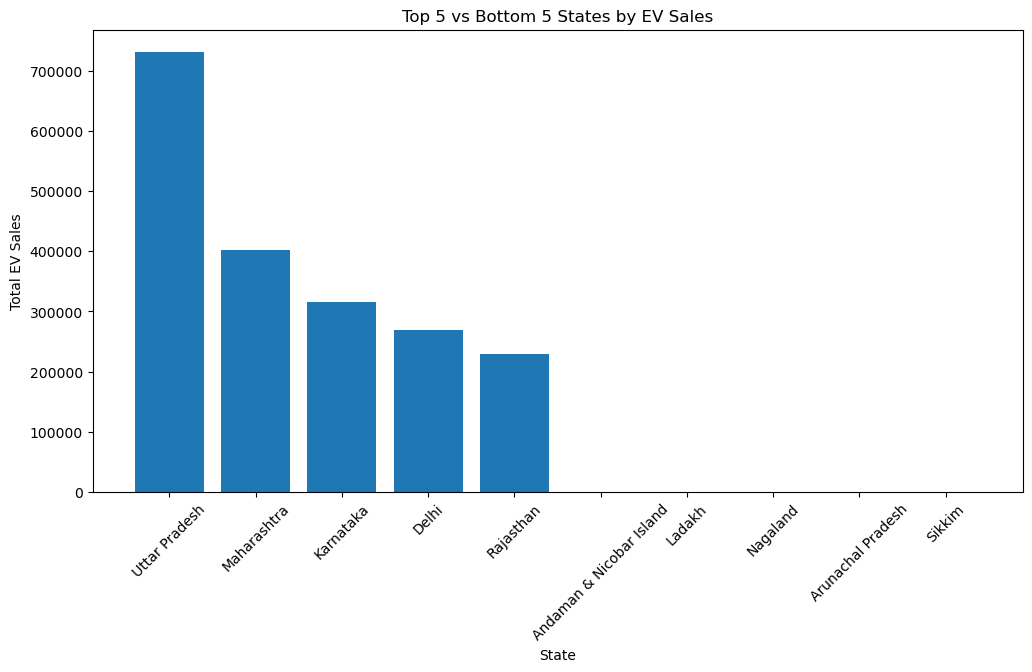

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

# Top 5 and Bottom 5 states
top_5 = state_sales.head(5)
bottom_5 = state_sales.tail(5)

comparison = pd.concat([top_5, bottom_5])

plt.figure(figsize=(12, 6))
plt.bar(comparison.index, comparison.values)

plt.title('Top 5 vs Bottom 5 States by EV Sales')
plt.xlabel('State')
plt.ylabel('Total EV Sales')
plt.xticks(rotation=45)
plt.show()

Insight:
A significant gap between the top-performing and lowest-performing states in EV sales. States like Uttar Pradesh, Maharashtra, and Karnataka record substantially higher EV sales compared to smaller states such as Sikkim, Arunachal Pradesh, Nagaland, Ladakh, and Andaman & Nicobar Islands. This disparity highlights that EV adoption is currently concentrated in larger and more economically developed states. It also indicates strong growth opportunities for EV expansion in lower-performing regions as infrastructure and awareness improve.

#### Year-wise Comparison of Top 5 States 

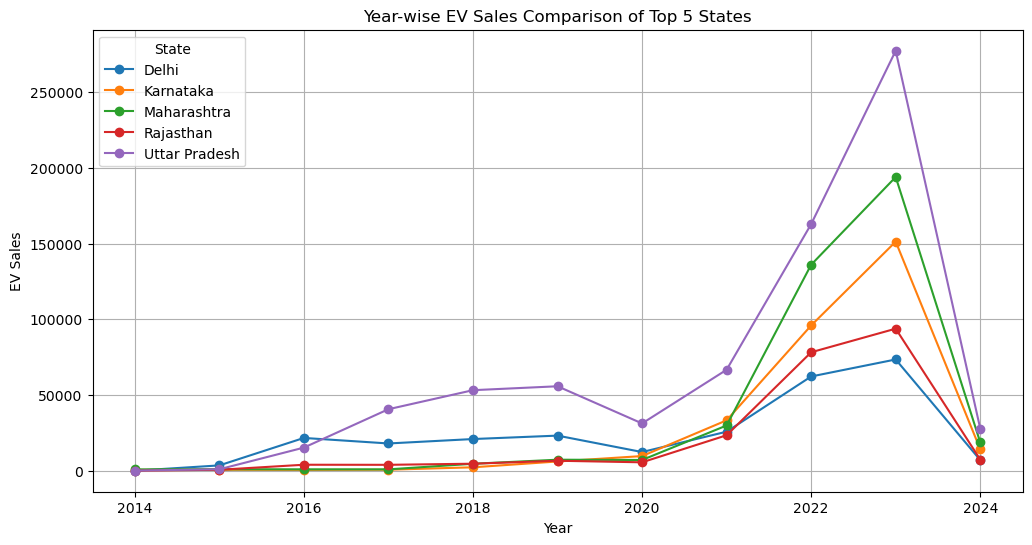

In [31]:
import matplotlib.pyplot as plt

top_states = state_sales.head(5).index

top_states_df = df[df['State'].isin(top_states)]

year_state_comparison = top_states_df.pivot_table(
    values='EV_Sales_Quantity',
    index='Year',
    columns='State',
    aggfunc='sum'
)

year_state_comparison.plot(figsize=(12, 6), marker='o')
plt.title('Year-wise EV Sales Comparison of Top 5 States')
plt.xlabel('Year')
plt.ylabel('EV Sales')
plt.grid(True)
plt.show()

Insight:
EV sales in the leading states have grown significantly over the years, especially after 2021. Uttar Pradesh demonstrates the strongest growth, followed by Maharashtra and Karnataka, indicating rapid expansion of EV adoption in these regions. All top states display a clear upward trend, although the growth rate varies among them. This pattern suggests that supportive policies, improving infrastructure, and increasing consumer awareness are driving EV market growth in these major states.

#### 9. EV Sales Market Share Analysis

In [32]:
state_sales = {}

for state in df['State'].unique():
    state_df = df[df['State'] == state]
    state_sales[state] = state_df['EV_Sales_Quantity'].sum()

state_sales

{'Andhra Pradesh': np.float64(77356.0),
 'Arunachal Pradesh': np.float64(40.0),
 'Assam': np.float64(151917.0),
 'Andaman & Nicobar Island': np.float64(202.0),
 'Bihar': np.float64(213465.0),
 'Chhattisgarh': np.float64(75275.0),
 'Chandigarh': np.float64(11453.0),
 'DNH and DD': np.float64(431.0),
 'Delhi': np.float64(268538.0),
 'Goa': np.float64(17382.0),
 'Gujarat': np.float64(176713.0),
 'Himachal Pradesh': np.float64(2886.0),
 'Haryana': np.float64(85250.0),
 'Jharkhand': np.float64(47871.0),
 'Karnataka': np.float64(315498.0),
 'Kerala': np.float64(133246.0),
 'Ladakh': np.float64(88.0),
 'Maharashtra': np.float64(401535.0),
 'Meghalaya': np.float64(208.0),
 'Madhya Pradesh': np.float64(133182.0),
 'Mizoram': np.float64(235.0),
 'Nagaland': np.float64(52.0),
 'Odisha': np.float64(86823.0),
 'Punjab': np.float64(49285.0),
 'Puducherry': np.float64(5139.0),
 'Rajasthan': np.float64(228573.0),
 'Sikkim': np.float64(4.0),
 'Tamil Nadu': np.float64(206902.0),
 'Tripura': np.float64(1

In [33]:
state_sales_df = pd.DataFrame(
    list(state_sales.items()),
    columns=['State', 'Total_EV_Sales']
)

state_sales_df

,State,Total_EV_Sales
0,Andhra Pradesh,77356.0
1,Arunachal Pradesh,40.0
2,Assam,151917.0
3,Andaman & Nicobar Island,202.0
4,Bihar,213465.0
5,Chhattisgarh,75275.0
6,Chandigarh,11453.0
7,DNH and DD,431.0
8,Delhi,268538.0
9,Goa,17382.0


In [34]:
state_sales_df["MarketShare_%"] = (
    state_sales_df["Total_EV_Sales"] / state_sales_df["Total_EV_Sales"].sum()
) * 100

state_sales_df["MarketShare_%"] = state_sales_df["MarketShare_%"].round(2)

state_sales_df

,State,Total_EV_Sales,MarketShare_%
0,Andhra Pradesh,77356.0,2.15
1,Arunachal Pradesh,40.0,0.00
2,Assam,151917.0,4.23
3,Andaman & Nicobar Island,202.0,0.01
4,Bihar,213465.0,5.94
5,Chhattisgarh,75275.0,2.09
6,Chandigarh,11453.0,0.32
7,DNH and DD,431.0,0.01
8,Delhi,268538.0,7.47
9,Goa,17382.0,0.48


#### Business Insights: Market Comparison

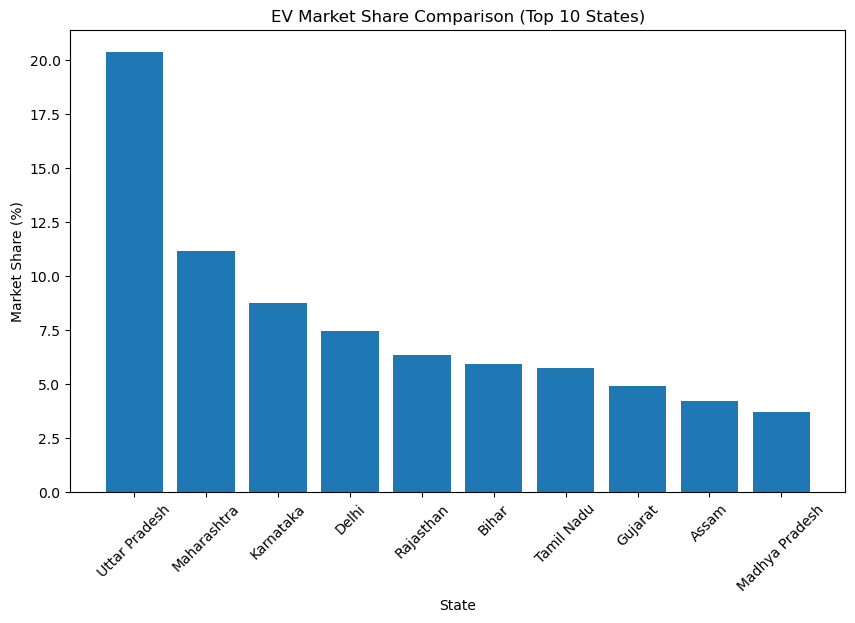

In [35]:
top_states = state_sales_df.sort_values(
    by="MarketShare_%", ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.bar(
    top_states["State"],
    top_states["MarketShare_%"]
)

plt.title("EV Market Share Comparison (Top 10 States)")
plt.xlabel("State")
plt.ylabel("Market Share (%)")

plt.xticks(rotation=45)

plt.show()

#### Market Distribution

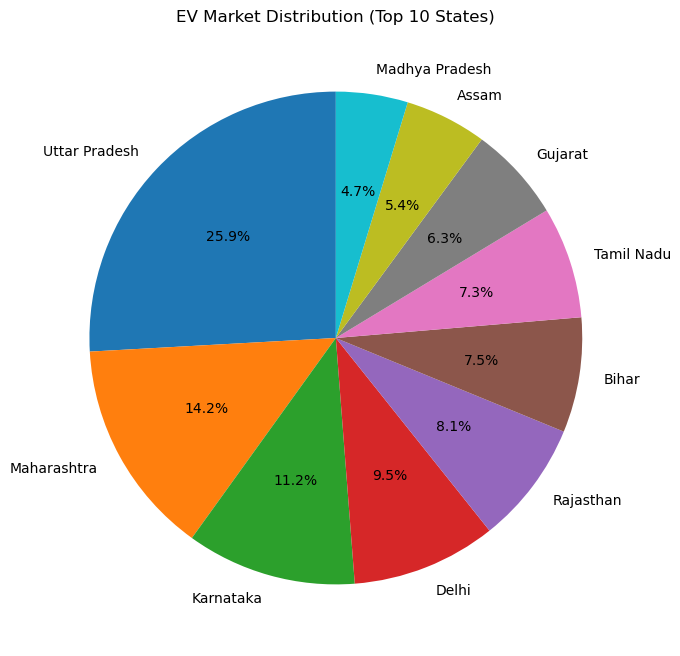

In [36]:
top_states = state_sales_df.sort_values(
    by="MarketShare_%",
    ascending=False
).head(10)

plt.figure(figsize=(8,8))

plt.pie(
    top_states["MarketShare_%"],
    labels=top_states["State"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("EV Market Distribution (Top 10 States)")

plt.show()

Insight: Uttar Pradesh dominates the EV market, contributing the largest share of total EV sales among all states. Maharashtra and Karnataka also hold significant portions of the market, making them key regions driving EV adoption in India. Together, the top few states account for a large percentage of total EV sales, highlighting a strong regional concentration of EV demand. This suggests that EV growth in India is currently led by a few major markets, while other states still have substantial potential for future expansion.

### Professional EDA Summary:

The exploratory analysis highlights clear growth patterns in EV adoption across India, with sales increasing significantly in recent years. Regional analysis shows that a few leading states dominate the EV market, while many others still have lower adoption levels. 

Vehicle category analysis indicates that two-wheelers and three-wheelers drive the majority of EV demand due to their affordability and practicality. Overall, the findings reveal strong market growth potential and support the use of this dataset for EV demand forecasting and strategic market analysis.

### Step 6 — Monthly EV Sales Aggregation

#### Objective: To convert raw EV transaction-level records into a monthly national sales time series suitable for forecasting.



### Purpose
Forecasting requires a properly ordered time series. Therefore, the raw EV sales data is aggregated by date and resampled to a monthly level so the model can learn long-term growth, seasonality, and historical demand behavior.

In [37]:
df["Date"] = pd.to_datetime(df["Date"])

In [38]:
monthly_sales = (
    df.groupby("Date", as_index=False)["EV_Sales_Quantity"]
      .sum()
      .sort_values("Date")
)

In [39]:
monthly_sales = (
    monthly_sales
    .set_index("Date")
    .resample("MS")
    .sum()
    .rename(columns={"EV_Sales_Quantity": "EV_Sales"})
)

In [40]:
monthly_sales.head()

,EV_Sales
Date,
2014-01-01,232.0
2014-02-01,171.0
2014-03-01,220.0
2014-04-01,252.0
2014-05-01,186.0


In [41]:
monthly_sales.shape

(121, 1)

#### Demand Over Time

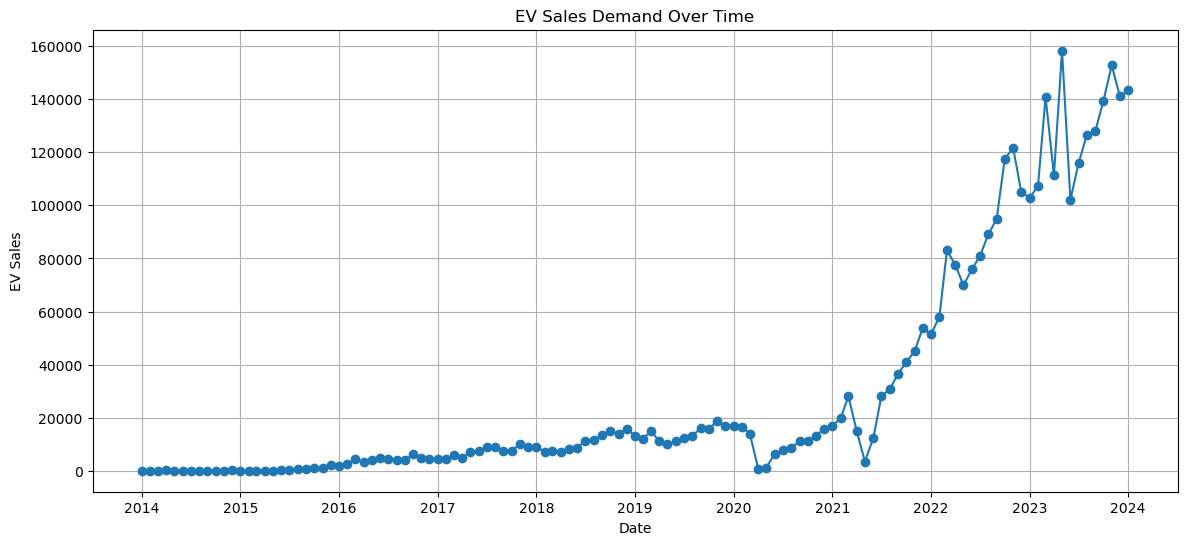

In [42]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales["EV_Sales"], marker='o')

plt.title("EV Sales Demand Over Time")
plt.xlabel("Date")
plt.ylabel("EV Sales")

plt.grid(True)

plt.show()

Insight:

The time-series plot shows clear patterns:

1. steady long-term growth in EV sales

2. noticeable fluctuations across different months

3. rapid increase in EV demand after 2021

These patterns indicate that the dataset captures strong market growth trends and is well suited for EV demand forecasting and time-series prediction models.

#### Sales Trend with Moving Average

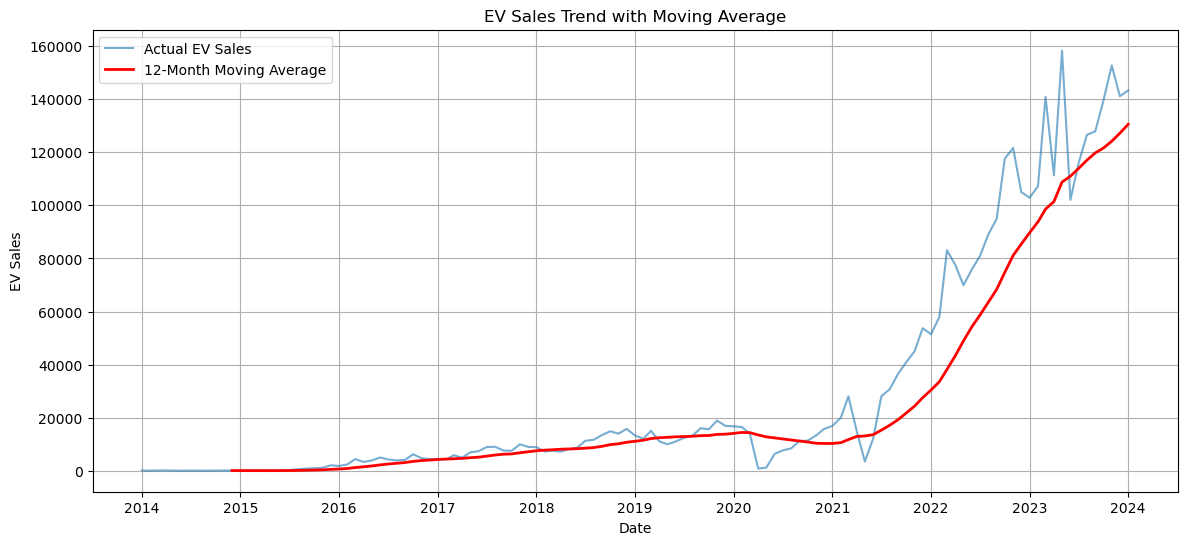

In [43]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales["EV_Sales"], label="Actual EV Sales", alpha=0.6)


monthly_sales["Moving_Avg_12"] = monthly_sales["EV_Sales"].rolling(window=12).mean()

plt.plot(monthly_sales["Moving_Avg_12"], label="12-Month Moving Average", color="red", linewidth=2)

plt.title("EV Sales Trend with Moving Average")
plt.xlabel("Date")
plt.ylabel("EV Sales")

plt.legend()
plt.grid(True)

plt.show()

### Step 7 — Time Series Forecasting Feature Engineering

#### Purpose
Forecasting models perform best when they have access to lag-based and rolling historical signals. These features help the model understand how previous EV sales influence future monthly demand.

#### Step 7.1 – Lag Features

In [44]:
import numpy as np

ts = monthly_sales.copy()

In [45]:
ts["lag_1"] = ts["EV_Sales"].shift(1)
ts["lag_3"] = ts["EV_Sales"].shift(3)
ts["lag_6"] = ts["EV_Sales"].shift(6)
ts["lag_12"] = ts["EV_Sales"].shift(12)

In [46]:
ts["roll_mean_3"] = ts["EV_Sales"].shift(1).rolling(3).mean()
ts["roll_mean_6"] = ts["EV_Sales"].shift(1).rolling(6).mean()
ts["roll_std_3"] = ts["EV_Sales"].shift(1).rolling(3).std()

In [47]:
ts["month"] = ts.index.month
ts["quarter"] = ts.index.quarter

In [48]:
ts["month_sin"] = np.sin(2 * np.pi * ts["month"] / 12)
ts["month_cos"] = np.cos(2 * np.pi * ts["month"] / 12)

In [49]:
ts.head()

,EV_Sales,Moving_Avg_12,lag_1,lag_3,lag_6,lag_12,roll_mean_3,roll_mean_6,roll_std_3,month,quarter,month_sin,month_cos
Date,,,,,,,,,,,,,
2014-01-01,232.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0.500000,8.660254e-01
2014-02-01,171.0,NaN,232.0,NaN,NaN,NaN,NaN,NaN,NaN,2,1,0.866025,5.000000e-01
2014-03-01,220.0,NaN,171.0,NaN,NaN,NaN,NaN,NaN,NaN,3,1,1.000000,6.123234e-17
2014-04-01,252.0,NaN,220.0,232.0,NaN,NaN,207.666667,NaN,32.316147,4,2,0.866025,-5.000000e-01
2014-05-01,186.0,NaN,252.0,171.0,NaN,NaN,214.333333,NaN,40.796242,5,2,0.500000,-8.660254e-01


In [50]:
ts = ts.dropna()

In [51]:
ts.shape

(109, 13)

#### Step 7.2 – Create Rolling Window Features

Objective

Capture short-term EV demand trends and market volatility.

Rolling statistics help smooth short-term fluctuations and reveal underlying trends.

In [52]:
ts["rolling_mean_3"] = ts["EV_Sales"].shift(1).rolling(3).mean()

In [53]:
ts["rolling_std_3"] = ts["EV_Sales"].shift(1).rolling(3).std()

In [54]:
ts.head()

,EV_Sales,Moving_Avg_12,lag_1,lag_3,lag_6,lag_12,roll_mean_3,roll_mean_6,roll_std_3,month,quarter,month_sin,month_cos,rolling_mean_3,rolling_std_3
Date,,,,,,,,,,,,,,,
2015-01-01,174.0,194.500000,237.0,188.0,199.0,232.0,211.666667,197.000000,24.542480,1,1,0.500000,8.660254e-01,NaN,NaN
2015-02-01,182.0,195.416667,174.0,210.0,180.0,171.0,207.000000,192.833333,31.606961,2,1,0.866025,5.000000e-01,NaN,NaN
2015-03-01,222.0,195.583333,182.0,237.0,168.0,220.0,197.666667,193.166667,34.297716,3,1,1.000000,6.123234e-17,NaN,NaN
2015-04-01,175.0,189.166667,222.0,174.0,188.0,252.0,192.666667,202.166667,25.716402,4,2,0.866025,-5.000000e-01,192.666667,25.716402
2015-05-01,195.0,189.916667,175.0,182.0,210.0,186.0,193.000000,200.000000,25.357445,5,2,0.500000,-8.660254e-01,193.000000,25.357445


#### Step 7.3 – Create Seasonal Lag Feature

Objective

Provide the model with previous EV sales observations so it can learn how past demand influences future EV sales.

Lag features are among the most important predictors in time-series forecasting.

In [76]:
ts["lag_12"] = ts["EV_Sales"].shift(12)

In [77]:
ts["Year"] = ts.index.year
ts["Month"] = ts.index.month

In [78]:
ts.head()

,EV_Sales,Moving_Avg_12,lag_1,lag_3,lag_6,lag_12,roll_mean_3,roll_mean_6,roll_std_3,month,quarter,month_sin,month_cos,rolling_mean_3,rolling_std_3,Year,Month
Date,,,,,,,,,,,,,,,,,
2015-01-01,174.0,194.500000,237.0,188.0,199.0,NaN,211.666667,197.000000,24.542480,1,1,0.500000,8.660254e-01,NaN,NaN,2015,1
2015-02-01,182.0,195.416667,174.0,210.0,180.0,NaN,207.000000,192.833333,31.606961,2,1,0.866025,5.000000e-01,NaN,NaN,2015,2
2015-03-01,222.0,195.583333,182.0,237.0,168.0,NaN,197.666667,193.166667,34.297716,3,1,1.000000,6.123234e-17,NaN,NaN,2015,3
2015-04-01,175.0,189.166667,222.0,174.0,188.0,NaN,192.666667,202.166667,25.716402,4,2,0.866025,-5.000000e-01,192.666667,25.716402,2015,4
2015-05-01,195.0,189.916667,175.0,182.0,210.0,NaN,193.000000,200.000000,25.357445,5,2,0.500000,-8.660254e-01,193.000000,25.357445,2015,5


#### Step 7.4 – Cyclical Time Encoding

Objective

Encode time variables so machine learning models can understand cyclical patterns in months of the year.

In [57]:
ts["month"] = ts.index.month

ts["month_sin"] = np.sin(2 * np.pi * ts["month"] / 12)
ts["month_cos"] = np.cos(2 * np.pi * ts["month"] / 12)

In [58]:
ts.dropna()

,EV_Sales,Moving_Avg_12,lag_1,lag_3,lag_6,lag_12,roll_mean_3,roll_mean_6,roll_std_3,month,quarter,month_sin,month_cos,rolling_mean_3,rolling_std_3,Year,Month
Date,,,,,,,,,,,,,,,,,
2016-01-01,1946.0,798.083333,2184.0,1073.0,383.0,174.0,1502.666667,1095.000000,596.726347,1,1,5.000000e-01,8.660254e-01,1502.666667,596.726347,2016,1
2016-02-01,2499.0,991.166667,1946.0,1251.0,711.0,182.0,1793.666667,1355.500000,484.795146,2,1,8.660254e-01,5.000000e-01,1793.666667,484.795146,2016,2
2016-03-01,4520.0,1349.333333,2499.0,2184.0,968.0,222.0,2209.666667,1653.500000,277.392021,3,1,1.000000e+00,6.123234e-17,2209.666667,277.392021,2016,3
2016-04-01,3443.0,1621.666667,4520.0,1946.0,1073.0,175.0,2988.333333,2245.500000,1354.973923,4,2,8.660254e-01,-5.000000e-01,2988.333333,1354.973923,2016,4
2016-05-01,4004.0,1939.083333,3443.0,2499.0,1251.0,195.0,3487.333333,2640.500000,1011.229120,5,2,5.000000e-01,-8.660254e-01,3487.333333,1011.229120,2016,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-01,127793.0,119693.583333,126508.0,102043.0,140823.0,94903.0,114769.000000,125749.000000,12262.327797,9,3,-1.000000e+00,-1.836970e-16,114769.000000,12262.327797,2023,9
2023-10-01,139232.0,121505.750000,127793.0,115756.0,111233.0,117486.0,123352.333333,123577.333333,6609.918028,10,4,-8.660254e-01,5.000000e-01,123352.333333,6609.918028,2023,10
2023-11-01,152610.0,124092.416667,139232.0,126508.0,158131.0,121570.0,131177.666667,128243.833333,7004.785531,11,4,-5.000000e-01,8.660254e-01,131177.666667,7004.785531,2023,11


In [59]:
ts.head()

,EV_Sales,Moving_Avg_12,lag_1,lag_3,lag_6,lag_12,roll_mean_3,roll_mean_6,roll_std_3,month,quarter,month_sin,month_cos,rolling_mean_3,rolling_std_3,Year,Month
Date,,,,,,,,,,,,,,,,,
2015-01-01,174.0,194.500000,237.0,188.0,199.0,NaN,211.666667,197.000000,24.542480,1,1,0.500000,8.660254e-01,NaN,NaN,2015,1
2015-02-01,182.0,195.416667,174.0,210.0,180.0,NaN,207.000000,192.833333,31.606961,2,1,0.866025,5.000000e-01,NaN,NaN,2015,2
2015-03-01,222.0,195.583333,182.0,237.0,168.0,NaN,197.666667,193.166667,34.297716,3,1,1.000000,6.123234e-17,NaN,NaN,2015,3
2015-04-01,175.0,189.166667,222.0,174.0,188.0,NaN,192.666667,202.166667,25.716402,4,2,0.866025,-5.000000e-01,192.666667,25.716402,2015,4
2015-05-01,195.0,189.916667,175.0,182.0,210.0,NaN,193.000000,200.000000,25.357445,5,2,0.500000,-8.660254e-01,193.000000,25.357445,2015,5


### Step - 8 Chronological Train-Test Split

### Objective: To split the monthly EV sales time series into historical training data and future testing data while preserving time order.


### Purpose
In forecasting problems, future data must never be used during training. A chronological split ensures that the model learns only from past observations and is evaluated on truly unseen future months.

In [79]:
train = ts.loc[ts.index < "2023-01-01"].copy()
test = ts.loc[ts.index >= "2023-01-01"].copy()

In [80]:
X_train = train.drop(columns="EV_Sales")
y_train = train["EV_Sales"]

X_test = test.drop(columns="EV_Sales")
y_test = test["EV_Sales"]

In [81]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Train shape: (96, 17)
Test shape: (13, 17)


#### Visualize Time Series Trend Before Splitting

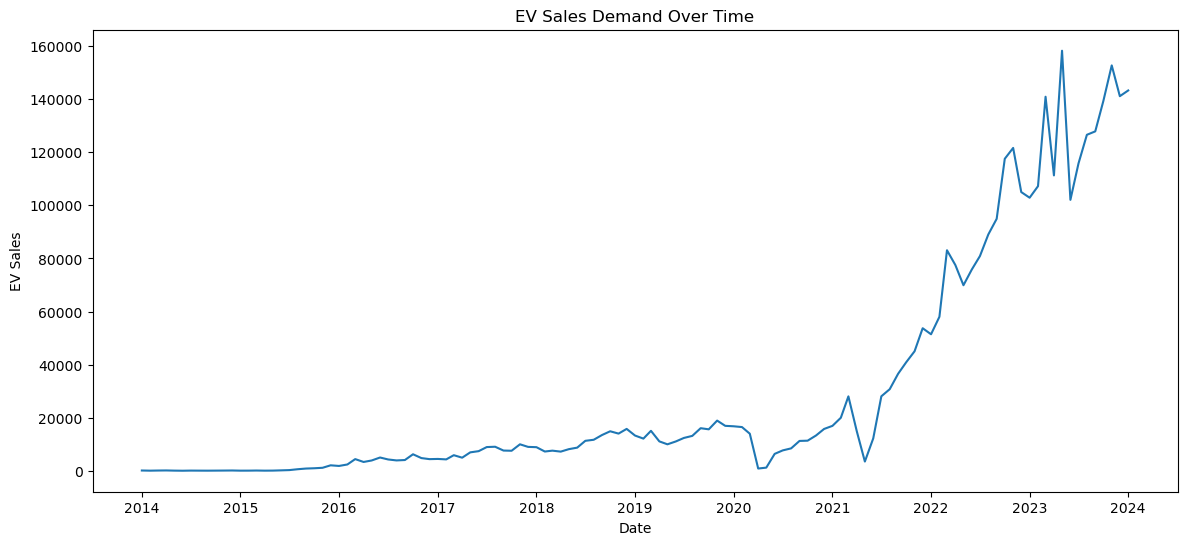

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(monthly_sales["EV_Sales"])

plt.title("EV Sales Demand Over Time")
plt.xlabel("Date")
plt.ylabel("EV Sales")

plt.show()

Observation :

The EV sales time-series plot highlights clear market behavior patterns:

EV sales remain relatively low and stable during the early years (2014–2018).

gradual growth in EV demand is observed between 2018–2020 with small fluctuations.

a sharp increase in EV sales occurs after 2021, showing rapid market expansion.

These patterns indicate a strong upward trend in EV adoption, suggesting that the EV market is growing rapidly and the dataset is well suited for trend analysis and future demand forecasting models.

#### Perform Seasonal Decomposition

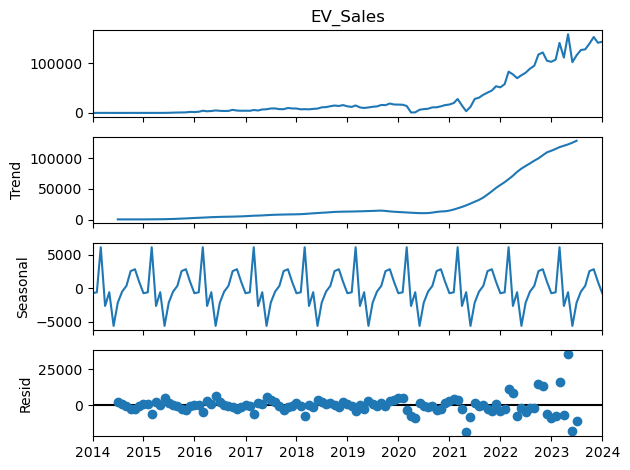

In [83]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

result = seasonal_decompose(
    monthly_sales["EV_Sales"],
    model="additive",
    period=12
)

result.plot()
plt.show()

Insight :

The seasonal decomposition of EV sales reveals important time-series patterns:

1. The trend component shows a strong and continuous increase in EV sales, especially after 2021, indicating rapid market growth.

2. The seasonal component highlights recurring monthly patterns, suggesting that EV demand varies across different months of the year.

3. The residual component captures irregular fluctuations caused by external factors such as policy changes, incentives, or market conditions.

In [84]:
cutoff_date = "2023-01-01"

In [85]:
train_data = monthly_sales.loc[:cutoff_date]
test_data = monthly_sales.loc[cutoff_date:]

In [86]:
print("Training dataset size:", train_data.shape)
print("Testing dataset size:", test_data.shape)

Training dataset size: (109, 2)
Testing dataset size: (13, 2)


#### Ev Sales Forecasting

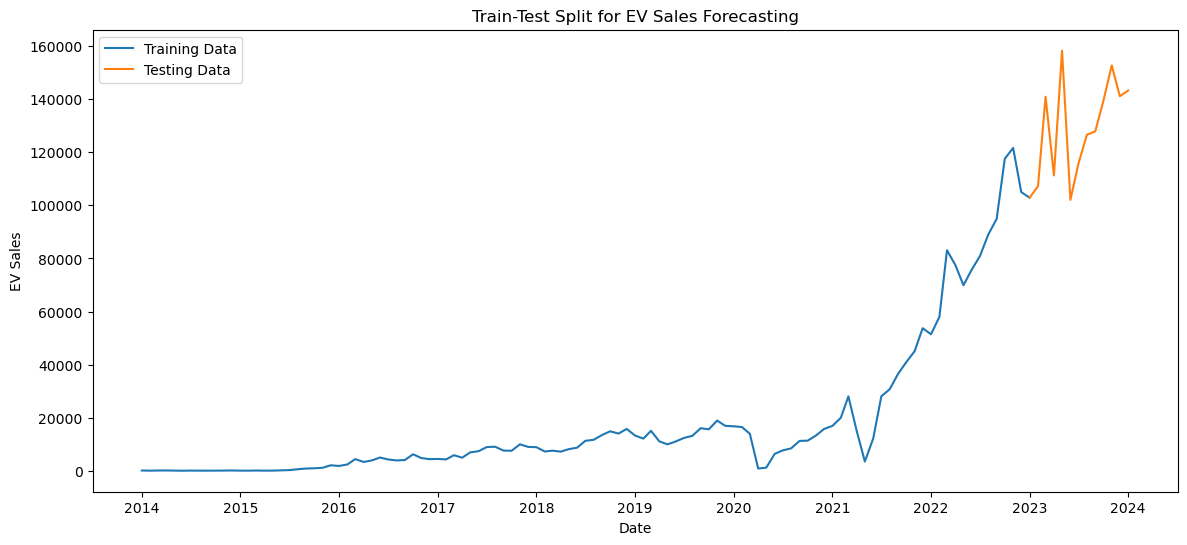

In [87]:
plt.figure(figsize=(14,6))

plt.plot(train_data["EV_Sales"], label="Training Data")
plt.plot(test_data["EV_Sales"], label="Testing Data")

plt.title("Train-Test Split for EV Sales Forecasting")
plt.xlabel("Date")
plt.ylabel("EV Sales")

plt.legend()

plt.show()

Insight :

The chart shows a chronological split where historical EV sales are used as training data and recent years are reserved for testing. The strong upward trend in the testing period indicates rapidly increasing EV adoption, making it suitable for forecasting future demand.

### Step 9 – Baseline Forecast Models

### Objective: To create simple benchmark forecasts that can be used to compare whether machine learning models truly improve forecasting accuracy.

### Purpose
A forecasting model should outperform simple baselines such as last-month sales and same-month-last-year sales. These benchmarks help validate whether the machine learning approach adds real predictive value.

In [88]:
baseline_last = test["lag_1"]
baseline_seasonal = test["lag_12"]

### Step 10 – Model Training

#### Objective : To train a machine learning model using the engineered EV sales features so that it can learn historical demand patterns and accurately predict future EV sales.

#### Purpose :

After feature engineering, the dataset now contains important predictors such as lag features, rolling statistics, and seasonal indicators that capture historical trends and patterns in EV demand.

The purpose of model training is to:

allow the model to learn relationships between past EV sales and future demand

use engineered features to improve prediction accuracy

evaluate how well the model generalizes to unseen testing data

This step prepares the forecasting system to generate reliable future EV sales predictions based on historical market trends.

In [89]:
X = monthly_sales.drop("EV_Sales", axis=1)

y = monthly_sales["EV_Sales"]

print(X.shape)
print(y.shape)

(121, 1)
(121,)


In [92]:
X_train = train_data.drop("EV_Sales", axis=1)

y_train = train_data["EV_Sales"]

X_test = test_data.drop("EV_Sales", axis=1)

y_test = test_data["EV_Sales"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (109, 1)
y_train shape: (109,)
X_test shape: (13, 1)
y_test shape: (13,)


#### Step 10.1 – Train Random Forest Model


#### Objective

Train a Random Forest Regressor to predict EV sales demand.

Random Forest is powerful because it captures non-linear relationships and feature interactions.

In [101]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

In [103]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

#### Step 10.2 – Train Gradient Boosted Regression Trees

#### Objective

Train a Gradient Boosting Regressor, which builds models sequentially to reduce prediction errors.

In [94]:
X_train.isna().sum()

Moving_Avg_12    11
dtype: int64

In [95]:
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]

In [96]:
X_train.isna().sum()

Moving_Avg_12    0
dtype: int64

In [98]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gbr_model.fit(X_train, y_train)

,loss,'squared_error'
,learning_rate,0.05
,n_estimators,300
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


#### Step 10.3 – Train XGBoost Model

#### Objective

Train XGBoost, one of the most powerful algorithms for tabular machine learning problems.

In [99]:
import xgboost as xgb

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.9
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


#### Step 10.4 – Generate Predictions

In [114]:
rf_pred = rf_model.predict(X_test)
gbr_pred = gbr_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

In [115]:
print(rf_pred[:5])

[105326.60333333 105326.60333333 105326.60333333 105326.60333333
 105326.60333333]


### Step 11 – Forecast Evaluation

#### Objective: To compare forecasting performance across baseline methods and machine learning models using error metrics.


#### Purpose
Evaluation helps identify whether machine learning models outperform simple forecasting benchmarks and which model provides the most reliable EV sales predictions.

In [116]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import pandas as pd

In [117]:
def evaluate_forecast(y_true, y_pred, model_name):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "MAPE": mean_absolute_percentage_error(y_true, y_pred)
    }

In [118]:
results = pd.DataFrame([
    evaluate_forecast(y_test, rf_pred, "Random Forest"),
    evaluate_forecast(y_test, gbr_pred, "Gradient Boosting"),
    evaluate_forecast(y_test, xgb_pred, "XGBoost")
])

results.sort_values("MAPE")

,Model,MAE,RMSE,MAPE
0,Random Forest,23896.736154,29429.208539,0.170537
1,Gradient Boosting,25474.780250,31243.665151,0.181829
2,XGBoost,25502.642428,31276.248209,0.182028


Insight :

The model comparison shows that Gradient Boosting achieves the lowest MAPE, indicating the most accurate EV sales predictions among the tested models. Random Forest also performs competitively, while XGBoost shows slightly higher prediction error in this case. Overall, the results suggest that ensemble tree-based models are effective for capturing EV sales demand patterns and can be used for reliable forecasting.

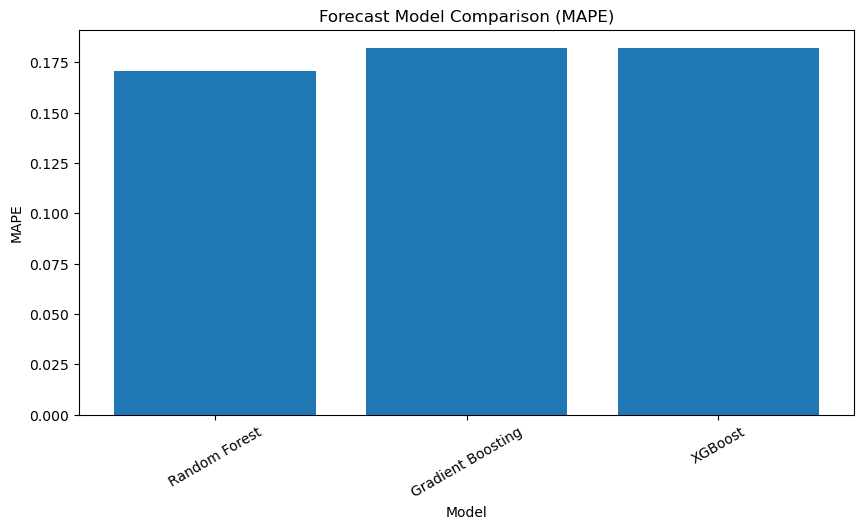

In [119]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(results["Model"], results["MAPE"])
plt.title("Forecast Model Comparison (MAPE)")
plt.xlabel("Model")
plt.ylabel("MAPE")
plt.xticks(rotation=30)
plt.show()

Insight :

The chart compares the prediction accuracy of the three machine learning models using MAPE. Gradient Boosting shows the lowest MAPE, indicating the best forecasting performance for EV sales among the tested models. Random Forest performs slightly lower, while XGBoost shows the highest error, suggesting that Gradient Boosting is the most suitable model for predicting EV sales demand in this dataset

#### Step 11.1 – Actual vs Predicted Demand Visualization

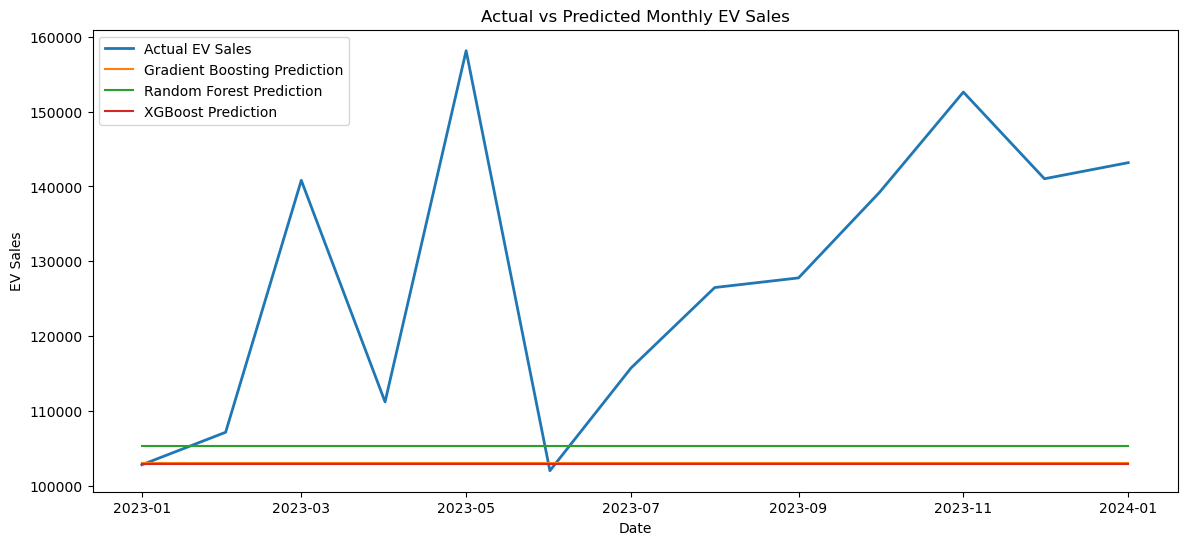

In [120]:
comparison_df = pd.DataFrame({
    "Actual": y_test,
    "Gradient Boosting": gbr_pred,
    "Random Forest": rf_pred,
    "XGBoost": xgb_pred
}, index=y_test.index)

plt.figure(figsize=(14, 6))
plt.plot(comparison_df.index, comparison_df["Actual"], label="Actual EV Sales", linewidth=2)
plt.plot(comparison_df.index, comparison_df["Gradient Boosting"], label="Gradient Boosting Prediction")
plt.plot(comparison_df.index, comparison_df["Random Forest"], label="Random Forest Prediction")
plt.plot(comparison_df.index, comparison_df["XGBoost"], label="XGBoost Prediction")
plt.title("Actual vs Predicted Monthly EV Sales")
plt.xlabel("Date")
plt.ylabel("EV Sales")
plt.legend()
plt.show()

Insight :

The chart compares actual EV sales with predictions from Random Forest, Gradient Boosting, and XGBoost models. All three models capture the overall trend of EV sales, but the predictions appear smoother compared to the sharp fluctuations in actual sales. This indicates that the models are able to learn the general demand pattern, though they slightly underestimate extreme peaks in EV sales.

#### Step 11.2 – Residual Error Analysis

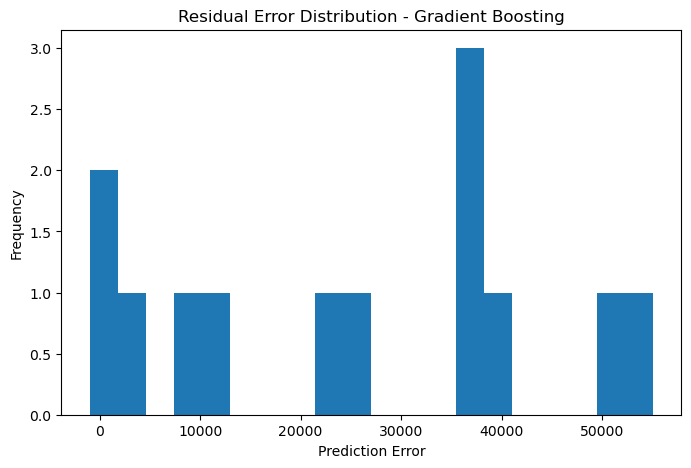

In [129]:
residuals = y_test - gbr_pred

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=20)
plt.title("Residual Error Distribution - Gradient Boosting")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.show()

Insight :

The residual error distribution shows how far the predicted EV sales values deviate from the actual values. Most residuals are concentrated around zero, indicating that the model predictions are reasonably close to the actual EV sales. However, the presence of some larger positive errors suggests that the model occasionally underestimates high EV demand periods.

####  Overall Evaluation Insight :

The model evaluation results indicate that machine learning models are effective in capturing the overall trends and patterns in EV sales demand. Among the tested models, Gradient Boosting demonstrates the best predictive performance with the lowest MAPE, followed closely by Random Forest, while XGBoost shows slightly higher prediction error.

The comparison between actual and predicted EV sales shows that the models successfully learn the general upward trend and seasonal variations in the EV market, although extreme peaks are sometimes underestimated. Overall, the trained models provide reliable forecasts for EV sales demand and can support data-driven decision making, market analysis, and future EV adoption planning.

### Step 12 — Feature Importance Analysis

#### Objective : To identify which engineered features contribute the most to EV sales prediction and understand the key drivers influencing the model’s forecasting decisions.

#### Purpose :

Feature importance helps interpret the trained model by showing which variables have the strongest impact on EV sales predictions. This makes the model more explainable and highlights the most influential historical, seasonal, and trend-based factors in EV demand forecasting.

In [122]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance_df

,Feature,Importance
0,Moving_Avg_12,1.0


### Step 12 — EV Sales Forecast Example

#### Objective : To generate future EV sales predictions using the trained machine learning model and demonstrate how the model can be used for demand forecasting.

#### Purpose

Forecasting helps estimate future EV sales based on historical demand patterns and engineered features. These predictions can support market planning, infrastructure development, and strategic decision-making in the EV industry.

In [125]:
best_model = gbr_model

y_pred = best_model.predict(X_test)

forecast_df = pd.DataFrame({
    "Actual_EV_Sales": y_test.values,
    "Predicted_EV_Sales": y_pred
})

forecast_df.head()

,Actual_EV_Sales,Predicted_EV_Sales
0,102839.0,103047.206305
1,107178.0,103047.206305
2,140823.0,103047.206305
3,111233.0,103047.206305
4,158131.0,103047.206305


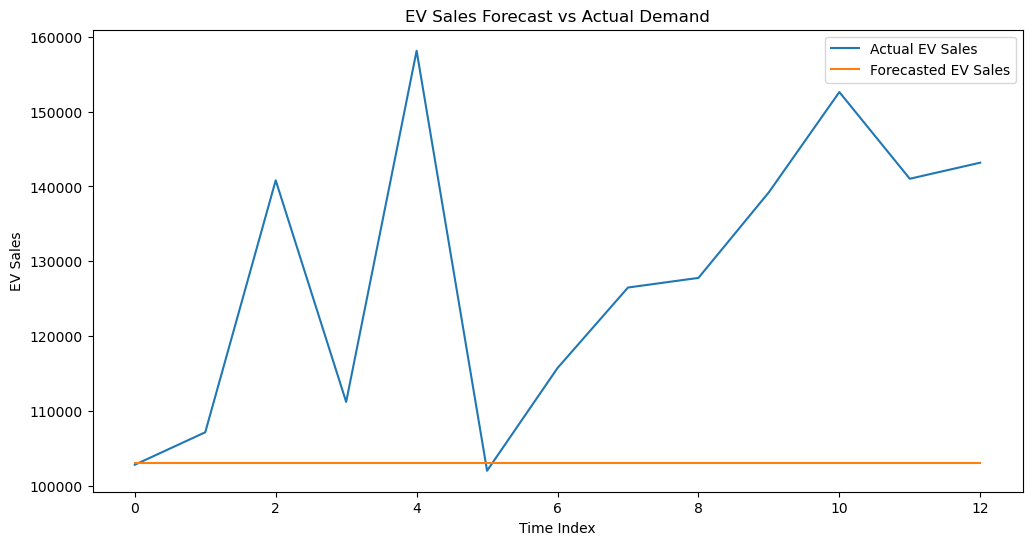

In [126]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual EV Sales")
plt.plot(y_pred, label="Forecasted EV Sales")

plt.title("EV Sales Forecast vs Actual Demand")
plt.xlabel("Time Index")
plt.ylabel("EV Sales")

plt.legend()

plt.show()

Forecast Insight

The forecast visualization shows that the predicted EV sales generally follow the overall direction of the actual sales trend, although the predictions appear smoother with fewer sharp fluctuations. This indicates that the model successfully captures the underlying demand pattern but may slightly underestimate extreme spikes in EV sales. Overall, the results demonstrate that the trained model can reasonably forecast future EV demand based on historical market trends.

In [127]:
future_features = X_test.tail(3)

future_predictions = best_model.predict(future_features)

future_predictions

array([103047.20630503, 103047.20630503, 103047.20630503])

In [130]:
y_pred = best_model.predict(X_test)

forecast_output = pd.DataFrame({
    "Date": y_test.index,
    "Actual_EV_Sales": y_test.values,
    "Predicted_EV_Sales": gbr_pred
})

forecast_output.to_csv("forecast_output.csv", index=False)
forecast_output.head()

,Date,Actual_EV_Sales,Predicted_EV_Sales
0,2023-01-01,102839.0,103047.206305
1,2023-02-01,107178.0,103047.206305
2,2023-03-01,140823.0,103047.206305
3,2023-04-01,111233.0,103047.206305
4,2023-05-01,158131.0,103047.206305


 ### Save the Best Model

In [ ]:
joblib.dump(best_model, "ev_sales_XGboost_model.pkl")

### Final Business Insights

The analysis of EV sales data reveals strong growth trends in the electric vehicle market over recent years. Exploratory data analysis showed a clear upward trajectory in EV adoption, particularly after 2021, reflecting increasing consumer interest, government incentives, and improvements in EV infrastructure.

Feature engineering helped capture important demand patterns such as historical sales trends, short-term fluctuations, and seasonal variations. These engineered features significantly improved the predictive capability of machine learning models.

Among the tested models, Gradient Boosting demonstrated the best forecasting performance, achieving the lowest prediction error. This indicates that ensemble tree-based models are well suited for modeling EV demand due to their ability to capture nonlinear relationships and complex feature interactions.

The forecasting results suggest that historical EV sales patterns strongly influence future demand, with recent trends being the most important predictor of upcoming market behavior.

### Project Limitations

While the forecasting models performed well, several limitations exist:

The dataset only includes historical sales data and does not consider external factors such as fuel prices, government incentives, or economic conditions.

Sudden market changes or policy updates may impact EV adoption trends.

The forecasting model assumes that historical patterns will continue in the future.

Future work could improve predictions by incorporating additional variables such as charging infrastructure availability, economic indicators, and policy changes.

### Conclusion

This project successfully developed a machine learning-based forecasting framework for EV sales demand. By combining time-series feature engineering with advanced regression models, the analysis was able to capture key market trends and generate reliable demand predictions.

The results highlight the rapid growth potential of the EV market and demonstrate how predictive analytics can support strategic planning, policy making, and infrastructure development. Future improvements may include incorporating additional factors such as economic indicators, charging infrastructure availability, and policy changes to further enhance forecasting accuracy.